In [22]:
import geopandas as gpd 
import geodatasets

In [23]:
gpd.__version__

'1.1.3'

In [24]:
gpd.datasets.available

[]

In [25]:
from geodatasets import get_path
nybb = gpd.read_file(get_path('nybb'))

In [26]:
print(type(nybb))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [27]:
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [28]:
nybb.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [29]:
nybb.describe()

,BoroCode,Shape_Leng,Shape_Area
count,5.000000,5.000000,5.000000e+00
mean,3.000000,558317.333911,1.685981e+09
std,1.581139,249002.452978,9.034868e+08
min,1.000000,330470.010332,6.364715e+08
25%,2.000000,359299.096471,1.186925e+09
50%,3.000000,464392.991824,1.623820e+09
75%,4.000000,741080.523166,1.937479e+09
max,5.000000,896344.047763,3.045213e+09


In [30]:
nybb.keys()

Index(['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry'], dtype='object')

Basic Geometry

In [31]:
import shapely 
shapely.__version__

'2.1.2'

In [21]:
from shapely.geometry import Point, LineString, Polygon, MultiPolygon

Creating a Point

In [32]:
point = Point(0,0)
type(point)

shapely.geometry.point.Point

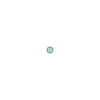

In [33]:
point

In [34]:
print(point)

POINT (0 0)


Create a LineString

In [35]:
point_1 = Point(0,0)
point_2 = Point(1.5,1.5)

points = [point_1,point_2]

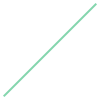

In [36]:
line = LineString(points)
line

In [37]:
print(line)

LINESTRING (0 0, 1.5 1.5)


Create a Polygon

In [38]:
point_1 = Point(0,0)
point_2 = Point(0,1)
point_3 = Point(1,1)
point_4 = Point(1,0)

points = [point_1, point_2, point_3,point_4]


In [39]:
polygon = Polygon(points)

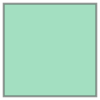

In [40]:
polygon

In [41]:
type(polygon)

shapely.geometry.polygon.Polygon

In [42]:
polygon.length

4.0

In [43]:
polygon.area

1.0

Creat Multi Geometries

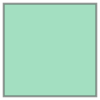

In [44]:
square = Polygon([(0,0),(0,1),(1,1),(1,0)])
square

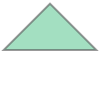

In [46]:
triangle = Polygon([(0,0),(1,1),(2,0)])
triangle

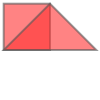

In [47]:
multipolygon = MultiPolygon([square, triangle])
multipolygon

In [48]:
print(type(multipolygon))

<class 'shapely.geometry.multipolygon.MultiPolygon'>


In [49]:
multipolygon.length

8.82842712474619

In [50]:
multipolygon.area

2.0

In [51]:
print(multipolygon)

MULTIPOLYGON (((0 0, 0 1, 1 1, 1 0, 0 0)), ((0 0, 1 1, 2 0, 0 0)))


Geometric Operations

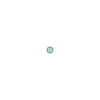

In [52]:
#Buffering geometries
point = Point(0,0)
point

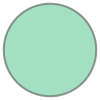

In [53]:
point_buffer = point.buffer(0.2)
point_buffer

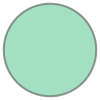

In [57]:
point_buffer = point.buffer(1.0)

point_buffer


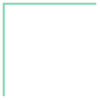

In [58]:
line = LineString([(0,0),(0,1),(1,1)])
line

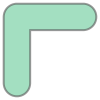

In [60]:
line_buffer = line.buffer(0.2)
line_buffer

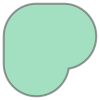

In [61]:
line_buffer = line.buffer(1.2)
line_buffer

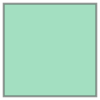

In [62]:
square = Polygon([(0,0),(0,1),(1,1),(1,0)])
square

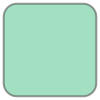

In [63]:
square.buffer(0.2)

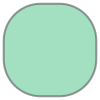

In [64]:
square.buffer(2.0)

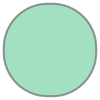

In [65]:
square.buffer(10.0)

Centroid


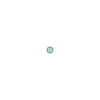

In [66]:
center_line = line.centroid
center_line

In [67]:
print(type(center_line))

<class 'shapely.geometry.point.Point'>


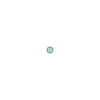

In [68]:
center_square = square.centroid
center_square

Convex Hull

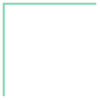

In [70]:
line 

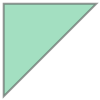

In [71]:
line.convex_hull

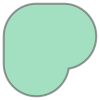

In [72]:
line_buffer

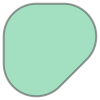

In [73]:
line_buffer.convex_hull

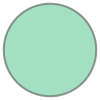

In [74]:
circle_1 = Point(0,0).buffer(2)
circle_2 = Point(3,0).buffer(2)
circle_1

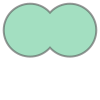

In [75]:
circle_1.union(circle_2)

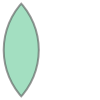

In [76]:
circle_1.intersection(circle_2)

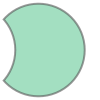

In [77]:
circle_2.difference(circle_1)

In [ ]:
#within command
point = Point(0,0)
triangle_1 = Polygon([(-1,-1),(0,1),(1,-1)])
triangle_2 = Polygon([(1,1),(2,0),(3,1)])
point.within(triangle_1)


False

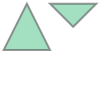

In [81]:
point.union(triangle_1).union(triangle_2)

Measuring Distance

In [82]:
point.distance(triangle_1)

0.0

In [83]:
point.distance(triangle_2)

1.4142135623730951

In [1]:
#Create GeodataFrame from scratch

from shapely.geometry import Point, LineString, Polygon,MultiPolygon

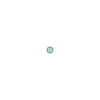

In [2]:
point = Point(0,0)
point

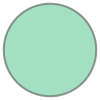

In [3]:
circle = point.buffer(0.5)
circle

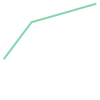

In [4]:
line = LineString([(2,2),(3.5,4),(7,5)])
line

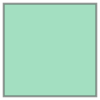

In [5]:
square = Polygon([(3,0),(3,1),(4,1),(4,0)])
square

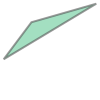

In [6]:
triangle = Polygon([(2,2+1.5),(3.5,4+1.5),(7,5+1.5)]).convex_hull
triangle

In [7]:
#Create a GeoDataFrame 
geo_data = {
    'point': point,
    'circle': circle,
    'line':line,
    'square': square,
    'triangle': triangle
}

geo_data
geo_data.keys()

dict_keys(['point', 'circle', 'line', 'square', 'triangle'])

In [8]:
geo_data.values()

dict_values([<POINT (0 0)>, <POLYGON ((0.5 0, 0.498 -0.049, 0.49 -0.098, 0.478 -0.145, 0.462 -0.191, 0.4...>, <LINESTRING (2 2, 3.5 4, 7 5)>, <POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))>, <POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))>])

In [9]:
import geopandas as gpd


In [10]:
gdf = gpd.GeoDataFrame(geo_data.items(), columns = ['geo_name','geometry'])
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [11]:
print(type(gdf))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [12]:
gdf['geometry_type'] = gdf['geometry'].apply(lambda x: type(x).__name__)
gdf

,geo_name,geometry,geometry_type
0,point,POINT (0 0),Point
1,circle,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",Polygon
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon


In [13]:
gdf['geometry_buffered'] = gdf['geometry'].apply(lambda x: x.buffer(0.5))
gdf

,geo_name,geometry,geometry_type,geometry_buffered
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
1,circle,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",Polygon,"POLYGON ((0.9994 0.02453, 0.9994 -0.02453, 0.9..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4...."
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0..."
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2...."


In [14]:
gdf['geometry_length'] = [g.length for g in gdf['geometry'].to_list()]
gdf['geometry_area'] = [g.area for g in gdf['geometry'].to_list()]

gdf

,geo_name,geometry,geometry_type,geometry_buffered,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",Polygon,"POLYGON ((0.9994 0.02453, 0.9994 -0.02453, 0.9...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


In [15]:
#visualizing synthentic data with geoPandas
import geopandas as gpd

In [16]:
gdf

,geo_name,geometry,geometry_type,geometry_buffered,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",Polygon,"POLYGON ((0.9994 0.02453, 0.9994 -0.02453, 0.9...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


Matplotlib is building the font cache; this may take a moment.


<Axes: >

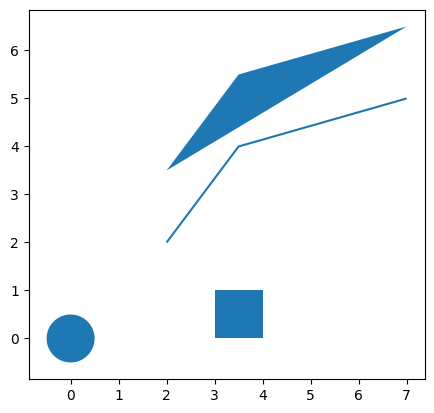

In [17]:
gdf.plot()

In [18]:
import matplotlib.pyplot as plt

<Axes: >

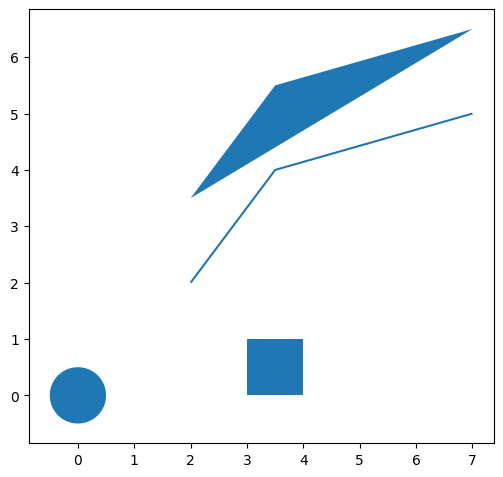

In [20]:
f , ax = plt.subplots(1,1, figsize=(6,6))
gdf.plot(ax = ax)

<Axes: >

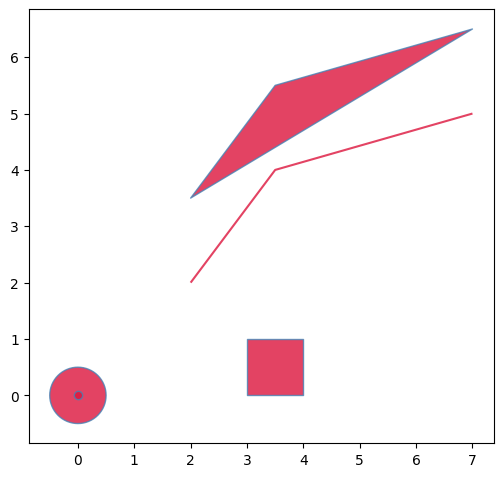

In [21]:
f , ax = plt.subplots(1,1, figsize=(6,6))
gdf.plot(ax = ax,
         color = 'crimson',
         edgecolor = 'steelblue',
         alpha = 0.8)

<Axes: >

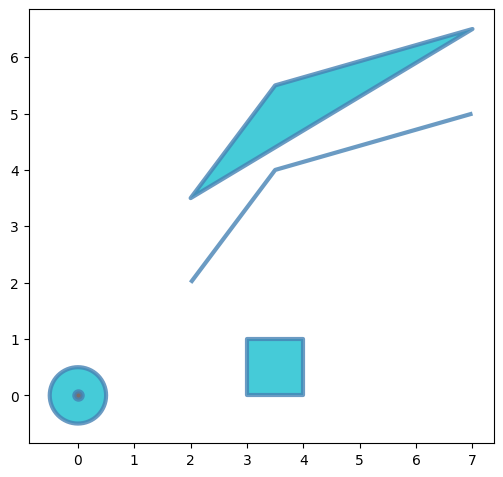

In [22]:
f , ax = plt.subplots(1,1, figsize=(6,6))

gdf.plot(ax = ax, 
         column = 'geometry_type',
         edgecolor = 'steelblue',
         linewidth = 3,
         alpha = 0.8)

<Axes: >

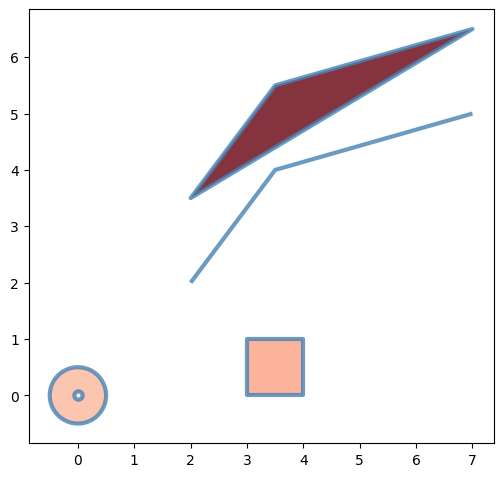

In [24]:
f , ax = plt.subplots(1,1, figsize=(6,6))

gdf.plot(ax = ax, 
         column = 'geometry_length',
         cmap = 'Reds',
         edgecolor = 'steelblue',
         linewidth = 3,
         alpha = 0.8)

In [25]:
from geodatasets import get_path
nybb = gpd.read_file(get_path('nybb'))

c:\Users\muzic\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [26]:
gdf = gpd.read_file(get_path('nybb'))
gdf

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [27]:
import matplotlib.pyplot as plt

<Axes: >

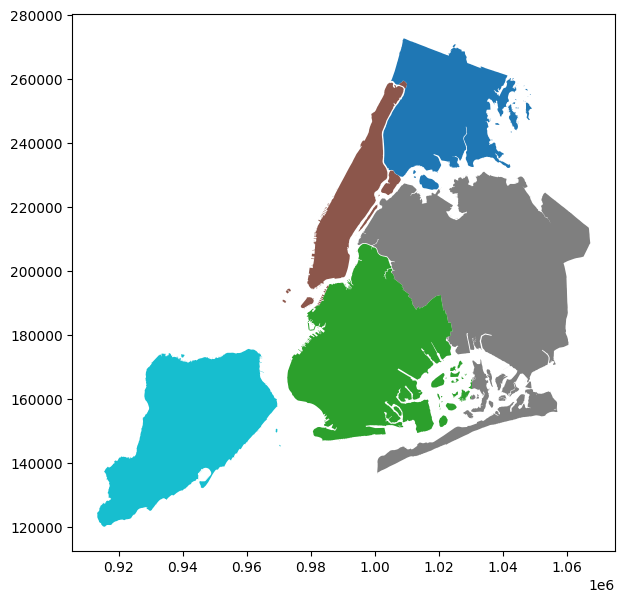

In [30]:
f, ax = plt.subplots(1,1, figsize=(7,7))
gdf.plot(ax = ax, column = 'BoroName', linewidth = 1.5, cmap='tab10')

(np.float64(905464.7390380859),
 np.float64(1075092.8783935546),
 np.float64(112485.76063504723),
 np.float64(280480.4142594267))

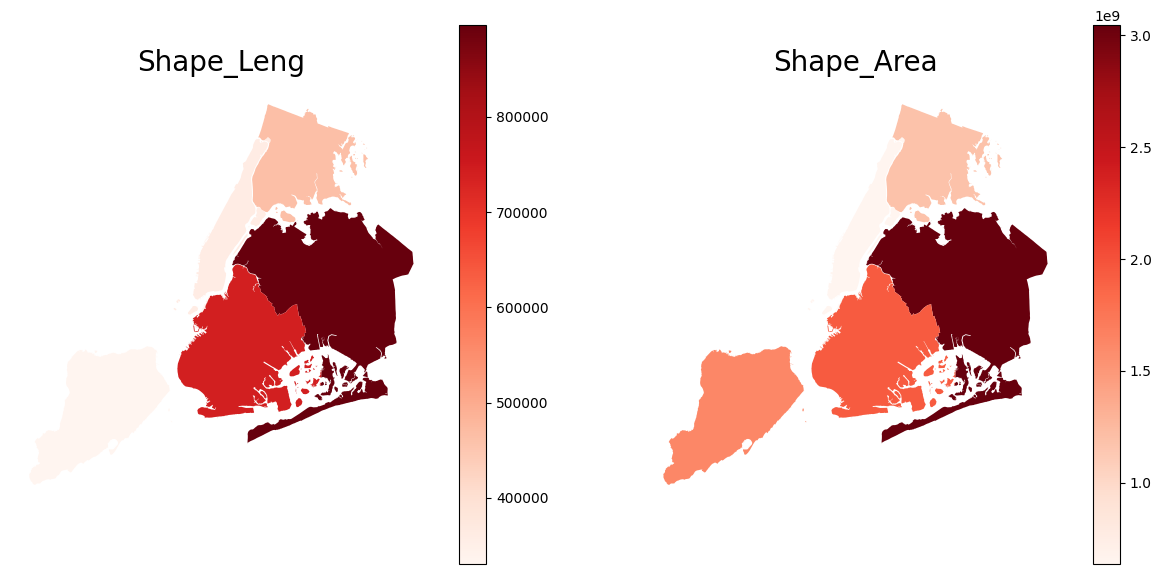

In [35]:
import matplotlib.pyplot as plt
f,ax = plt.subplots(1,2,figsize=(15,7))
gdf.plot(column = 'Shape_Leng',ax = ax[0],cmap = 'Reds',legend = True)
gdf.plot(column = 'Shape_Area', ax=ax[1],cmap='Reds',legend = True)

ax[0].set_title('Shape_Leng',fontsize = 20,pad=10)
ax[1].set_title('Shape_Area',fontsize = 20,pad=10)

ax[0].axis('off')
ax[1].axis('off')

In [36]:
#Map Projections

import geopandas as gpd


In [37]:
nybb = gpd.read_file(get_path('nybb'))

In [41]:
import geodatasets
print(geodatasets.data.keys())

dict_keys(['geoda', 'ny', 'eea', 'abs', 'naturalearth', 'spdata', 'eurostat'])


In [44]:
world = gpd.read_file(get_path('naturalearth.land'))

In [46]:
world.head(3)

,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."


In [47]:
print(nybb.crs)

EPSG:2263


In [48]:
nybb.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [49]:
world_nyc = world.to_crs('2236')

In [50]:
print(world_nyc.crs)

EPSG:2236


c:\Users\muzic\AppData\Local\Programs\Python\Python310\lib\site-packages\shapely\constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)
c:\Users\muzic\AppData\Local\Programs\Python\Python310\lib\site-packages\shapely\constructive.py:829: RuntimeWarning: invalid value encountered in normalize
  return lib.normalize(geometry, **kwargs)


<Axes: >

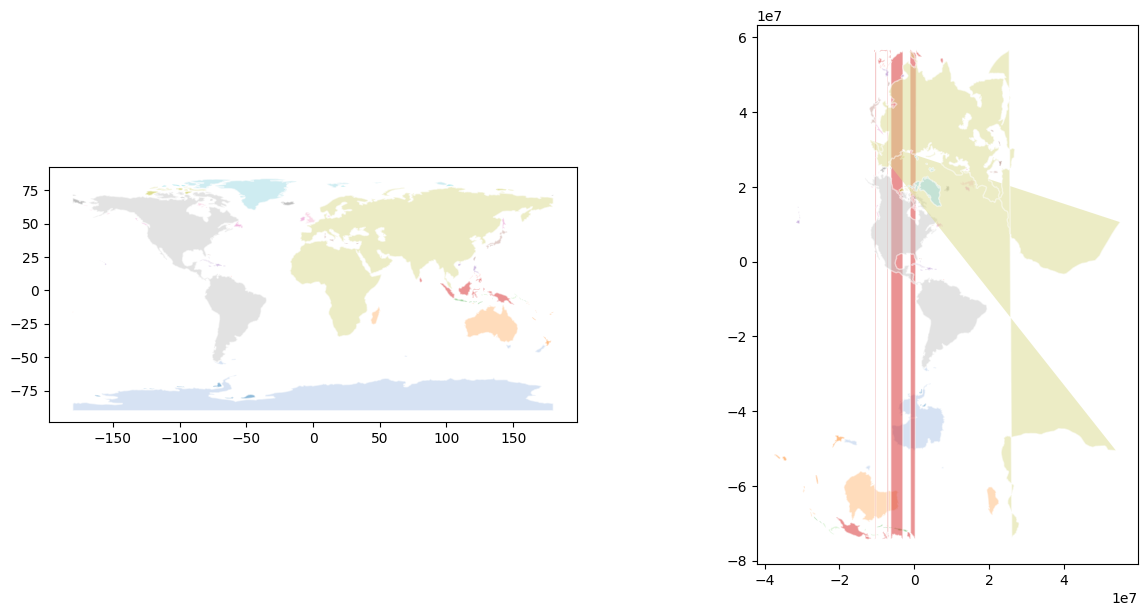

In [54]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,2,figsize=(15,7))
world.plot(ax = ax[0],edgecolor = 'w',cmap='tab20',alpha = 0.5, linewidth = 1)
world_nyc.plot(ax = ax[1],edgecolor = 'w',cmap='tab20',alpha = 0.5, linewidth = 1)

In [55]:
gpd.read_parquet("s3://us-west-2.opendata.source.coop/ftw/global-data/features/cogs/alpha/index.parquet")

FileNotFoundError: [Errno 2] Path does not exist 'us-west-2.opendata.source.coop/ftw/global-data/features/cogs/alpha/index.parquet'. Detail: [errno 2] No such file or directory